# 자전거 대여량 예측 프로젝트 — 분석·가설검정·모델링 완성본

## 미션 목표
자전거 대여 시스템 데이터를 활용해 **대여 수요 패턴을 분석**하고, 최종적으로 **RMSLE를 낮추는 예측 모델**을 구축한다.

## 분석 흐름
1. 데이터 로드 및 기본 점검
2. 파생 변수 생성
3. EDA: 시간, 요일, 계절, 날씨, 근무일 패턴 분석
4. 가설검정: 관찰된 패턴이 통계적으로 유의한지 검정
5. 모델링: RMSLE 기준 모델 비교
6. 피처 중요도 및 오차 분석
7. 운영 전략 제안 및 제출 파일 생성

## 핵심 주의점
- `count = casual + registered`이므로, `casual`, `registered`는 **train 데이터에서만 관찰되는 사후 결과 변수**이다.
- test 데이터에는 `casual`, `registered`, `count`가 없으므로, 모델 피처에는 절대 사용하지 않는다.
- RMSLE는 로그 기반 지표이므로 모델 학습 시 `log1p(count)`를 타깃으로 사용하면 평가 지표와 목적이 일치한다.


# 1. 환경 설정 및 라이브러리 로드


In [ ]:
# Colab/로컬 공통 패키지 설치 및 Colab 한글 폰트 설치
# - Colab에서는 Nanum 폰트를 설치해 matplotlib 한글 깨짐을 방지합니다.
# - 로컬 환경에서는 apt-get을 실행하지 않고, 아래 환경 설정 셀에서 OS별 기본 한글 폰트를 탐색합니다.
import sys
import subprocess

try:
    import google.colab
    IN_COLAB = True
except Exception:
    IN_COLAB = False

# 필수 패키지 설치
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'lightgbm', 'statsmodels', 'koreanize_matplotlib'], check=False)

# Colab 한글 폰트 설치
if IN_COLAB:
    subprocess.run(['apt-get', '-qq', 'update'], check=False)
    subprocess.run(['apt-get', '-qq', 'install', '-y', 'fonts-nanum'], check=False)


In [ ]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from itertools import combinations
import os
import platform

import numpy as np
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt
from matplotlib import font_manager as fm
import seaborn as sns

from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_log_error

try:
    from lightgbm import LGBMRegressor
    LGBM_AVAILABLE = True
except Exception:
    LGBM_AVAILABLE = False

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


def set_korean_font():
    """matplotlib/seaborn 그래프에서 한글이 깨지지 않도록 폰트를 설정합니다.

    우선순위
    1. Colab/Linux: NanumGothic
    2. Windows: Malgun Gothic
    3. macOS: AppleGothic / Apple SD Gothic Neo
    4. koreanize_matplotlib fallback
    """
    font_candidates = [
        '/usr/share/fonts/truetype/nanum/NanumGothic.ttf',
        '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf',
        'C:/Windows/Fonts/malgun.ttf',
        'C:/Windows/Fonts/malgunbd.ttf',
        '/System/Library/Fonts/AppleGothic.ttf',
        '/System/Library/Fonts/Supplemental/AppleGothic.ttf',
        '/System/Library/Fonts/AppleSDGothicNeo.ttc',
        '/Library/Fonts/AppleGothic.ttf',
    ]

    for font_path in font_candidates:
        if Path(font_path).exists():
            fm.fontManager.addfont(font_path)
            font_name = fm.FontProperties(fname=font_path).get_name()
            plt.rcParams['font.family'] = font_name
            plt.rcParams['axes.unicode_minus'] = False
            sns.set_theme(style='whitegrid', font=font_name)
            print(f'한글 폰트 설정 완료: {font_name}')
            return font_name

    try:
        import koreanize_matplotlib
        plt.rcParams['axes.unicode_minus'] = False
        sns.set_theme(style='whitegrid')
        print('koreanize_matplotlib 기반 한글 폰트 설정 완료')
        return str(plt.rcParams.get('font.family'))
    except Exception as e:
        plt.rcParams['axes.unicode_minus'] = False
        sns.set_theme(style='whitegrid')
        print('한글 폰트를 자동 설정하지 못했습니다.')
        print('Colab이라면 위 패키지/폰트 설치 셀을 먼저 실행한 뒤, 이 셀을 다시 실행하세요.')
        print('오류:', e)
        return None


KOREAN_FONT = set_korean_font()
print('현재 matplotlib font.family:', plt.rcParams['font.family'])


한글 폰트 설정 완료: NanumGothic
현재 matplotlib font.family: ['NanumGothic']


## 한글 그래프 제목 깨짐 방지 안내

그래프 제목이나 축 이름의 한글이 네모(□)로 깨지면, 위의 **패키지/폰트 설치 셀**과 **환경 설정 셀**을 순서대로 다시 실행하세요. Colab에서 그래도 깨질 경우 `런타임 > 세션 다시 시작` 후 처음부터 실행하면 해결됩니다.


# 2. 데이터 로드 및 기본 점검

아래 경로는 사용자의 기존 Colab 경로를 우선 사용하도록 두었습니다. 실행 환경에서 경로가 다르면 `TRAIN_PATH`, `TEST_PATH`만 수정하면 됩니다.


In [ ]:
from google.colab import drive
try:
    drive.mount('/content/drive')
except Exception as e:
    print('Google Drive mount를 건너뜁니다:', e)


Mounted at /content/drive


In [ ]:
# 필요하면 이 두 줄만 본인 경로에 맞게 수정하세요.
TRAIN_PATH = "/content/drive/MyDrive/코드잇_DA_13기_이현재/미션 12/train%20(1).csv"
TEST_PATH  = "/content/drive/MyDrive/코드잇_DA_13기_이현재/미션 12/test%20(1).csv"

# 경로 후보: 파일명이 train (1).csv 형태인 경우도 대비합니다.
candidate_train_paths = [
    TRAIN_PATH,
    TRAIN_PATH.replace('%20', ' '),
    './train.csv', './train (1).csv', '/content/train.csv', '/content/train (1).csv'
]
candidate_test_paths = [
    TEST_PATH,
    TEST_PATH.replace('%20', ' '),
    './test.csv', './test (1).csv', '/content/test.csv', '/content/test (1).csv'
]

def resolve_path(candidates):
    for p in candidates:
        if Path(p).exists():
            return p
    raise FileNotFoundError(
        '데이터 파일을 찾지 못했습니다. TRAIN_PATH / TEST_PATH를 현재 파일 위치에 맞게 수정하세요.\n'
        f'확인한 후보 경로: {candidates}'
    )

train_path = resolve_path(candidate_train_paths)
test_path = resolve_path(candidate_test_paths)

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

train_df['datetime'] = pd.to_datetime(train_df['datetime'])
test_df['datetime'] = pd.to_datetime(test_df['datetime'])

print('train path:', train_path)
print('test path :', test_path)
print('train shape:', train_df.shape)
print('test shape :', test_df.shape)


train path: /content/drive/MyDrive/코드잇_DA_13기_이현재/미션 12/train%20(1).csv
test path : /content/drive/MyDrive/코드잇_DA_13기_이현재/미션 12/test%20(1).csv
train shape: (10886, 12)
test shape : (6493, 9)


In [ ]:
display(train_df.head())
display(test_df.head())


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed
0,2011-01-20 00:00:00,1,0,1,1,10.66,11.365,56,26.0027
1,2011-01-20 01:00:00,1,0,1,1,10.66,13.635,56,0.0000
2,2011-01-20 02:00:00,1,0,1,1,10.66,13.635,56,0.0000
3,2011-01-20 03:00:00,1,0,1,1,10.66,12.880,56,11.0014
4,2011-01-20 04:00:00,1,0,1,1,10.66,12.880,56,11.0014


In [ ]:
print('[train info]')
display(train_df.info())

print('\n[test info]')
display(test_df.info())


[train info]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   datetime    10886 non-null  datetime64[ns]
 1   season      10886 non-null  int64         
 2   holiday     10886 non-null  int64         
 3   workingday  10886 non-null  int64         
 4   weather     10886 non-null  int64         
 5   temp        10886 non-null  float64       
 6   atemp       10886 non-null  float64       
 7   humidity    10886 non-null  int64         
 8   windspeed   10886 non-null  float64       
 9   casual      10886 non-null  int64         
 10  registered  10886 non-null  int64         
 11  count       10886 non-null  int64         
dtypes: datetime64[ns](1), float64(3), int64(8)
memory usage: 1020.7 KB


None


[test info]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6493 entries, 0 to 6492
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   datetime    6493 non-null   datetime64[ns]
 1   season      6493 non-null   int64         
 2   holiday     6493 non-null   int64         
 3   workingday  6493 non-null   int64         
 4   weather     6493 non-null   int64         
 5   temp        6493 non-null   float64       
 6   atemp       6493 non-null   float64       
 7   humidity    6493 non-null   int64         
 8   windspeed   6493 non-null   float64       
dtypes: datetime64[ns](1), float64(3), int64(5)
memory usage: 456.7 KB


None

In [ ]:
print('train 결측치')
display(train_df.isna().sum().to_frame('missing_count'))

print('test 결측치')
display(test_df.isna().sum().to_frame('missing_count'))


train 결측치


,missing_count
datetime,0
season,0
holiday,0
workingday,0
weather,0
temp,0
atemp,0
humidity,0
windspeed,0
casual,0


test 결측치


,missing_count
datetime,0
season,0
holiday,0
workingday,0
weather,0
temp,0
atemp,0
humidity,0
windspeed,0


In [ ]:
# 수치형 기술통계
train_df.describe().T


,count,mean,min,25%,50%,75%,max,std
datetime,10886,2011-12-27 05:56:22.399411968,2011-01-01 00:00:00,2011-07-02 07:15:00,2012-01-01 20:30:00,2012-07-01 12:45:00,2012-12-19 23:00:00,NaN
season,10886.0,2.506614,1.0,2.0,3.0,4.0,4.0,1.116174
holiday,10886.0,0.028569,0.0,0.0,0.0,0.0,1.0,0.166599
workingday,10886.0,0.680875,0.0,0.0,1.0,1.0,1.0,0.466159
weather,10886.0,1.418427,1.0,1.0,1.0,2.0,4.0,0.633839
temp,10886.0,20.23086,0.82,13.94,20.5,26.24,41.0,7.79159
atemp,10886.0,23.655084,0.76,16.665,24.24,31.06,45.455,8.474601
humidity,10886.0,61.88646,0.0,47.0,62.0,77.0,100.0,19.245033
windspeed,10886.0,12.799395,0.0,7.0015,12.998,16.9979,56.9969,8.164537
casual,10886.0,36.021955,0.0,4.0,17.0,49.0,367.0,49.960477


## 2-1. 데이터 점검 결론

- 결측치가 없다면 별도 결측치 대체는 필요하지 않다.
- `datetime`은 그 자체로는 모델이 해석하기 어렵기 때문에 `hour`, `weekday`, `month`, `year` 등으로 분해한다.
- `casual`, `registered`는 `count`의 구성 요소이지만 test 데이터에 없으므로 모델 피처에서 제외한다.


# 3. 파생 변수 생성

시간 데이터는 자전거 수요 예측에서 가장 중요한 축이다. 따라서 단순히 `datetime`을 제거하지 않고, 운영 해석이 가능한 변수로 분해한다.


In [ ]:
def create_features(df):
    # 자전거 수요 예측용 파생 변수를 생성하는 함수.
    df = df.copy()
    df['datetime'] = pd.to_datetime(df['datetime'])

    df['year'] = df['datetime'].dt.year
    df['month'] = df['datetime'].dt.month
    df['day'] = df['datetime'].dt.day
    df['hour'] = df['datetime'].dt.hour
    df['weekday'] = df['datetime'].dt.weekday  # 0=월, 6=일
    df['weekofyear'] = df['datetime'].dt.isocalendar().week.astype(int)
    df['dayofyear'] = df['datetime'].dt.dayofyear

    df['is_weekend'] = df['weekday'].isin([5, 6]).astype(int)
    df['is_month_start'] = df['datetime'].dt.is_month_start.astype(int)
    df['is_month_end'] = df['datetime'].dt.is_month_end.astype(int)

    # 출퇴근 피크: EDA에서 확인한 7~9시, 17~19시 구간
    df['morning_rush'] = df['hour'].isin([7, 8, 9]).astype(int)
    df['evening_rush'] = df['hour'].isin([17, 18, 19]).astype(int)
    df['rush_hour'] = ((df['morning_rush'] == 1) | (df['evening_rush'] == 1)).astype(int)

    df['commute_direction'] = np.select(
        [df['morning_rush'].eq(1), df['evening_rush'].eq(1)],
        ['morning_commute', 'evening_commute'],
        default='other'
    )

    df['day_part'] = pd.cut(
        df['hour'],
        bins=[-1, 5, 11, 16, 20, 23],
        labels=['새벽', '오전', '오후', '저녁', '밤']
    )

    # 순환형 시간 피처: 23시와 0시가 멀지 않다는 정보를 모델에 전달
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
    df['weekday_sin'] = np.sin(2 * np.pi * df['weekday'] / 7)
    df['weekday_cos'] = np.cos(2 * np.pi * df['weekday'] / 7)
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

    # 날씨 상호작용 피처
    df['temp_humidity'] = df['temp'] * df['humidity']
    df['temp_windspeed'] = df['temp'] * df['windspeed']
    df['humidity_windspeed'] = df['humidity'] * df['windspeed']
    df['comfort_index'] = df['temp'] - 0.55 * (1 - df['humidity'] / 100) * (df['temp'] - 14.5)

    return df

train_fe = create_features(train_df)
test_fe = create_features(test_df)

train_fe['log_count'] = np.log1p(train_fe['count'])

print(train_fe.shape, test_fe.shape)
display(train_fe.head())


(10886, 38) (6493, 34)


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,...,hour_cos,weekday_sin,weekday_cos,month_sin,month_cos,temp_humidity,temp_windspeed,humidity_windspeed,comfort_index,log_count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,...,1.000000,-0.974928,-0.222521,0.5,0.866025,797.04,0.0,0.0,10.32697,2.833213
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,...,0.965926,-0.974928,-0.222521,0.5,0.866025,721.60,0.0,0.0,9.62280,3.713572
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,...,0.866025,-0.974928,-0.222521,0.5,0.866025,721.60,0.0,0.0,9.62280,3.496508
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,...,0.707107,-0.974928,-0.222521,0.5,0.866025,738.00,0.0,0.0,10.48075,2.639057
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,...,0.500000,-0.974928,-0.222521,0.5,0.866025,738.00,0.0,0.0,10.48075,0.693147


# 4. EDA: 자전거 대여 패턴 분석

EDA의 목적은 단순히 그래프를 그리는 것이 아니라, 이후 가설검정과 모델 피처 설계로 연결할 수 있는 패턴을 찾는 것이다.


In [ ]:
# 공통 시각화 설정
weekday_labels = ['월', '화', '수', '목', '금', '토', '일']
season_labels = {1: '봄', 2: '여름', 3: '가을', 4: '겨울'}
weather_labels = {1: '맑음', 2: '구름/안개', 3: '약한 비/눈', 4: '폭우/폭설'}


## 4-1. 시간대별 대여 패턴

관찰 포인트: 출근 시간과 퇴근 시간에 대여량이 증가하는지 확인한다.


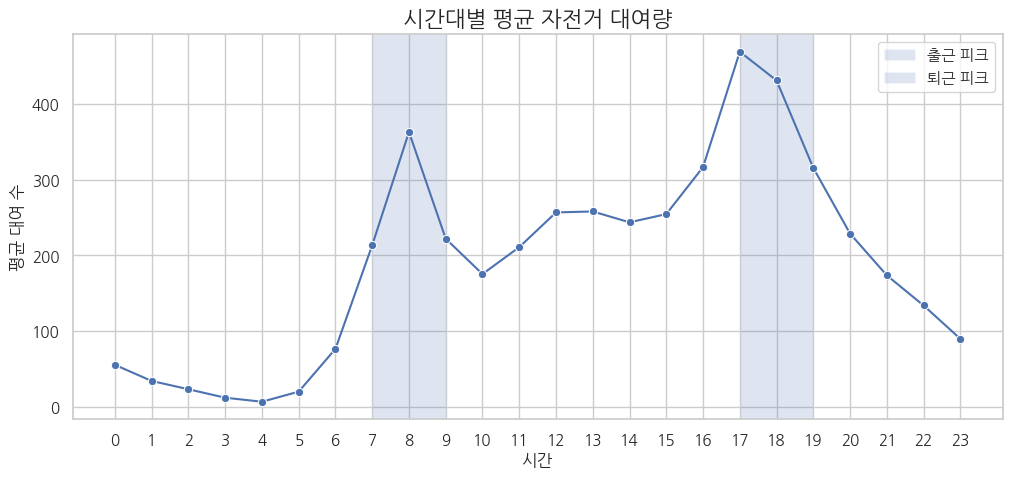

In [ ]:
hourly = train_fe.groupby('hour')['count'].mean()

plt.figure(figsize=(12, 5))
sns.lineplot(x=hourly.index, y=hourly.values, marker='o')
plt.axvspan(7, 9, alpha=0.18, label='출근 피크')
plt.axvspan(17, 19, alpha=0.18, label='퇴근 피크')
plt.title('시간대별 평균 자전거 대여량', fontsize=16, fontweight='bold')
plt.xlabel('시간')
plt.ylabel('평균 대여 수')
plt.xticks(range(24))
plt.legend()
plt.show()


**해석 방향**  
시간대별 수요가 균등하지 않다면, 모델에는 `hour`, `rush_hour`, `morning_rush`, `evening_rush`, `hour_sin/cos` 같은 시간 피처가 반드시 필요하다.


## 4-2. 요일 × 시간대 히트맵

관찰 포인트: 평일 출퇴근형 수요와 주말 레저형 수요가 구분되는지 확인한다.


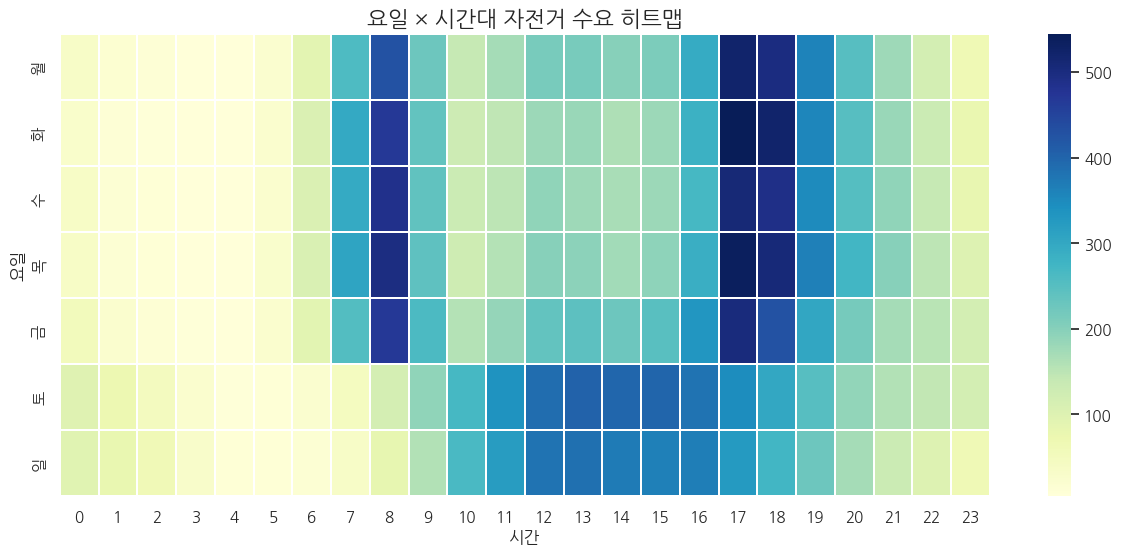

In [ ]:
pivot = train_fe.pivot_table(
    values='count',
    index='weekday',
    columns='hour',
    aggfunc='mean'
)
pivot.index = weekday_labels

plt.figure(figsize=(15, 6))
sns.heatmap(pivot, cmap='YlGnBu', linewidths=0.2)
plt.title('요일 × 시간대 자전거 수요 히트맵', fontsize=16, fontweight='bold')
plt.xlabel('시간')
plt.ylabel('요일')
plt.show()


**한 줄 인사이트**  
평일은 출퇴근 시간대 중심으로 수요가 집중되고, 주말은 상대적으로 낮 시간대 수요가 분산되는 패턴이 나타난다.

**모델 피처 연결**  
이 패턴은 `hour`만으로 설명하기 어렵기 때문에 `weekday`, `workingday`, `is_weekend`, `rush_hour`, `hour × workingday` 성격의 변수를 함께 반영해야 한다.


## 4-3. 날씨별 대여량 분포

관찰 포인트: 날씨가 악화될수록 대여량이 감소하는지 확인한다.


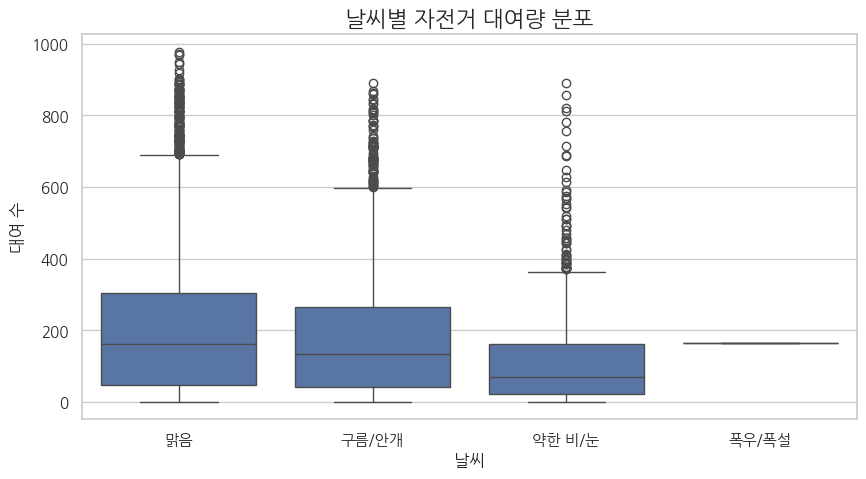

In [ ]:
plot_df = train_fe.copy()
plot_df['weather_name'] = plot_df['weather'].map(weather_labels)

plt.figure(figsize=(10, 5))
sns.boxplot(x='weather_name', y='count', data=plot_df, order=list(weather_labels.values()))
plt.title('날씨별 자전거 대여량 분포', fontsize=16, fontweight='bold')
plt.xlabel('날씨')
plt.ylabel('대여 수')
plt.show()


## 4-4. 계절별 대여량 분포


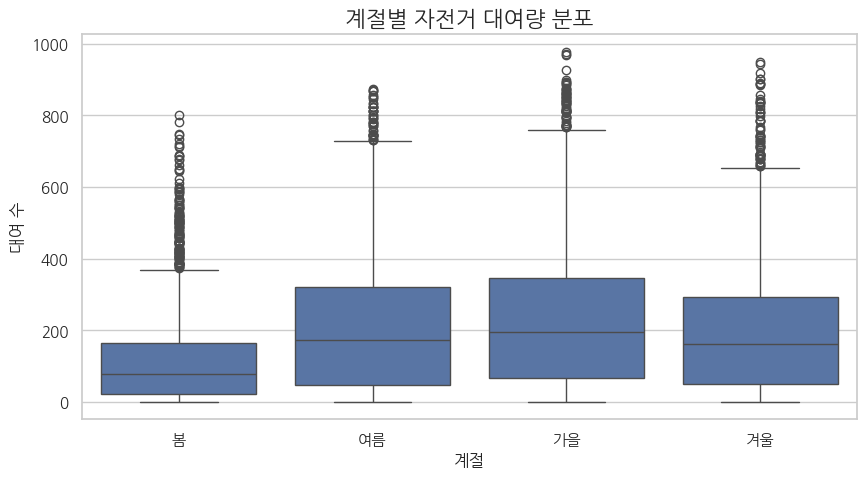

In [ ]:
plot_df = train_fe.copy()
plot_df['season_name'] = plot_df['season'].map(season_labels)

plt.figure(figsize=(10, 5))
sns.boxplot(x='season_name', y='count', data=plot_df, order=list(season_labels.values()))
plt.title('계절별 자전거 대여량 분포', fontsize=16, fontweight='bold')
plt.xlabel('계절')
plt.ylabel('대여 수')
plt.show()


## 4-5. 평일과 주말/공휴일 수요 비교


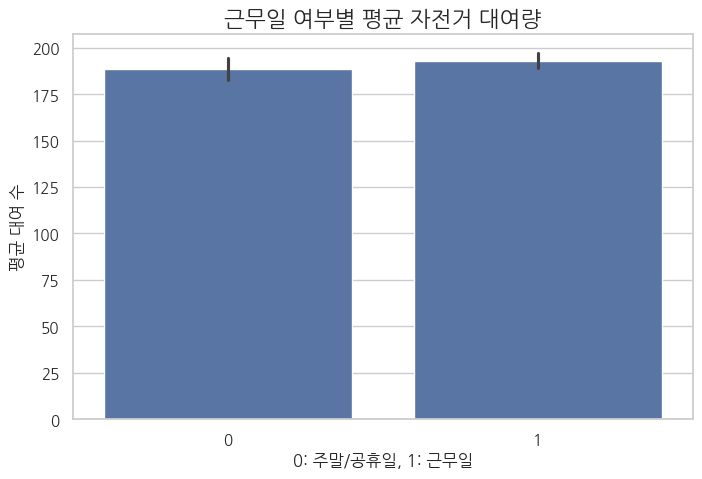

In [ ]:
plt.figure(figsize=(8, 5))
sns.barplot(x='workingday', y='count', data=train_fe, estimator='mean')
plt.title('근무일 여부별 평균 자전거 대여량', fontsize=16, fontweight='bold')
plt.xlabel('0: 주말/공휴일, 1: 근무일')
plt.ylabel('평균 대여 수')
plt.show()


## 4-6. 등록 사용자와 비등록 사용자 패턴 비교

`casual`, `registered`는 예측 모델에는 사용할 수 없지만, 운영 인사이트를 위해 train 데이터에서만 분석할 수 있다.


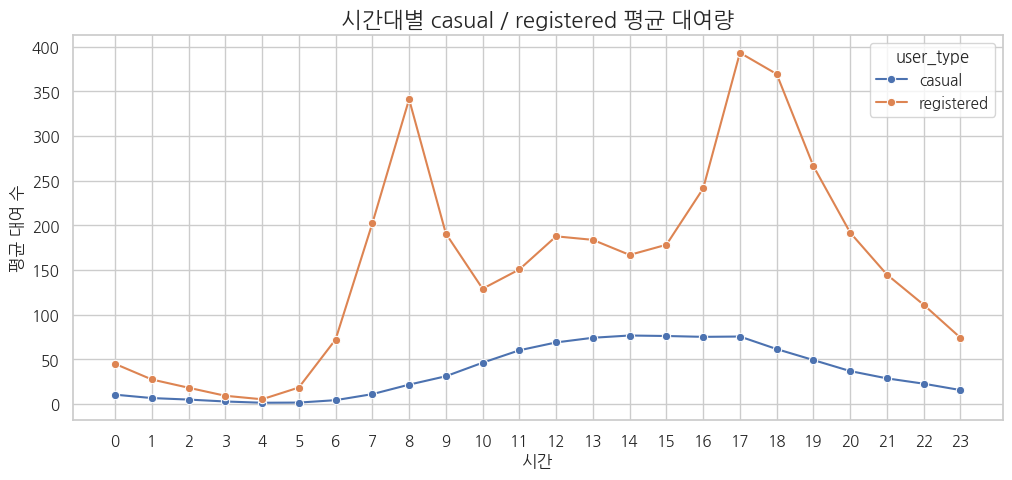

In [ ]:
if {'casual', 'registered'}.issubset(train_fe.columns):
    user_hourly = train_fe.groupby('hour')[['casual', 'registered']].mean().reset_index()
    user_hourly_melt = user_hourly.melt(id_vars='hour', value_vars=['casual', 'registered'],
                                       var_name='user_type', value_name='mean_count')

    plt.figure(figsize=(12, 5))
    sns.lineplot(data=user_hourly_melt, x='hour', y='mean_count', hue='user_type', marker='o')
    plt.title('시간대별 casual / registered 평균 대여량', fontsize=16, fontweight='bold')
    plt.xlabel('시간')
    plt.ylabel('평균 대여 수')
    plt.xticks(range(24))
    plt.show()
else:
    print('casual/registered 컬럼이 없어 해당 EDA는 건너뜁니다.')


# 5. 가설검정

EDA에서 확인한 패턴이 우연히 나타난 것인지, 통계적으로 유의한 차이인지 검정한다.

## 검정 설계 원칙
- 대여량 `count`는 오른쪽으로 긴 분포를 갖기 쉽기 때문에 원본 `count`와 함께 `log1p(count)`를 사용한다.
- 두 집단 비교는 Welch t-test와 Mann-Whitney U test를 함께 확인한다.
- 세 집단 이상 비교는 Kruskal-Wallis test를 사용하고, 필요한 경우 사후검정을 수행한다.
- p-value만 보지 않고 평균/중앙값/효과크기까지 함께 본다.


In [ ]:
def summarize_by_group(df, group_col, value_col='count'):
    return (
        df.groupby(group_col)[value_col]
        .agg(['count', 'mean', 'median', 'std', 'min', 'max'])
        .reset_index()
    )


def cohen_d(x, y):
    x = pd.Series(x).dropna()
    y = pd.Series(y).dropna()
    nx, ny = len(x), len(y)
    if nx < 2 or ny < 2:
        return np.nan
    pooled_std = np.sqrt(((nx - 1) * x.var(ddof=1) + (ny - 1) * y.var(ddof=1)) / (nx + ny - 2))
    if pooled_std == 0:
        return np.nan
    return (x.mean() - y.mean()) / pooled_std


def two_group_test(df, group_col, group_a, group_b, value_col='log_count'):
    a = df.loc[df[group_col] == group_a, value_col].dropna()
    b = df.loc[df[group_col] == group_b, value_col].dropna()

    t_stat, t_p = stats.ttest_ind(a, b, equal_var=False)
    u_stat, u_p = stats.mannwhitneyu(a, b, alternative='two-sided')
    d = cohen_d(a, b)

    result = pd.DataFrame({
        'group_a': [group_a],
        'group_b': [group_b],
        'n_a': [len(a)],
        'n_b': [len(b)],
        'mean_a': [a.mean()],
        'mean_b': [b.mean()],
        'median_a': [a.median()],
        'median_b': [b.median()],
        'welch_t_p': [t_p],
        'mannwhitney_p': [u_p],
        'cohen_d_on_log': [d]
    })
    return result


def kruskal_group_test(df, group_col, value_col='log_count'):
    groups = [g[value_col].dropna() for _, g in df.groupby(group_col)]
    h_stat, p_value = stats.kruskal(*groups)
    return pd.DataFrame({
        'group_col': [group_col],
        'H_statistic': [h_stat],
        'p_value': [p_value]
    })


def pairwise_mannwhitney(df, group_col, value_col='log_count', alpha=0.05):
    rows = []
    labels = sorted(df[group_col].dropna().unique())

    for a, b in combinations(labels, 2):
        x = df.loc[df[group_col] == a, value_col].dropna()
        y = df.loc[df[group_col] == b, value_col].dropna()
        if len(x) < 2 or len(y) < 2:
            continue
        u_stat, p = stats.mannwhitneyu(x, y, alternative='two-sided')
        rows.append({
            'group_a': a,
            'group_b': b,
            'n_a': len(x),
            'n_b': len(y),
            'median_a': x.median(),
            'median_b': y.median(),
            'raw_p': p
        })

    result = pd.DataFrame(rows)
    if len(result) > 0:
        reject, p_adj, _, _ = multipletests(result['raw_p'], alpha=alpha, method='holm')
        result['p_adj_holm'] = p_adj
        result['reject_H0'] = reject
    return result.sort_values('p_adj_holm') if len(result) > 0 else result


def decision_text(p, alpha=0.05):
    return '귀무가설 기각: 통계적으로 유의한 차이가 있음' if p < alpha else '귀무가설 기각 실패: 통계적으로 유의한 차이를 확인하지 못함'


## 5-1. 가설 1: 근무일과 주말/공휴일의 대여 수요는 다르다

- H0: 근무일과 주말/공휴일의 평균 대여량에는 차이가 없다.
- H1: 근무일과 주말/공휴일의 평균 대여량에는 차이가 있다.


In [ ]:
display(summarize_by_group(train_fe, 'workingday', 'count'))

h1_result = two_group_test(
    train_fe,
    group_col='workingday',
    group_a=1,
    group_b=0,
    value_col='log_count'
)
display(h1_result)
print('[H1 결론]', decision_text(h1_result.loc[0, 'mannwhitney_p']))


,workingday,count,mean,median,std,min,max
0,0,3474,188.506621,128.0,173.724015,1,783
1,1,7412,193.011873,151.0,184.513659,1,977


,group_a,group_b,n_a,n_b,mean_a,mean_b,median_a,median_b,welch_t_p,mannwhitney_p,cohen_d_on_log
0,1,0,7412,3474,4.57647,4.623139,5.023881,4.859812,0.097975,0.967914,-0.03288


[H1 결론] 귀무가설 기각 실패: 통계적으로 유의한 차이를 확인하지 못함


## 5-2. 가설 2: 출퇴근 시간대의 수요는 비출퇴근 시간대보다 높다

- H0: 출퇴근 시간대와 비출퇴근 시간대의 대여량에는 차이가 없다.
- H1: 출퇴근 시간대와 비출퇴근 시간대의 대여량에는 차이가 있다.


In [ ]:
display(summarize_by_group(train_fe, 'rush_hour', 'count'))

h2_result = two_group_test(
    train_fe,
    group_col='rush_hour',
    group_a=1,
    group_b=0,
    value_col='log_count'
)
display(h2_result)
print('[H2 결론]', decision_text(h2_result.loc[0, 'mannwhitney_p']))


,rush_hour,count,mean,median,std,min,max
0,0,8153,143.326628,106.0,140.280566,1,783
1,1,2733,335.504574,306.0,210.588297,1,977


,group_a,group_b,n_a,n_b,mean_a,mean_b,median_a,median_b,welch_t_p,mannwhitney_p,cohen_d_on_log
0,1,0,2733,8153,5.545038,4.271679,5.726848,4.672829,0.0,0.0,0.973732


[H2 결론] 귀무가설 기각: 통계적으로 유의한 차이가 있음


## 5-3. 가설 3: 계절별 대여 수요에는 차이가 있다

- H0: 계절별 대여량 분포에는 차이가 없다.
- H1: 적어도 하나의 계절은 다른 계절과 대여량 분포가 다르다.


In [ ]:
season_summary = summarize_by_group(train_fe, 'season', 'count')
season_summary['season_name'] = season_summary['season'].map(season_labels)
display(season_summary)

h3_result = kruskal_group_test(train_fe, 'season', 'log_count')
display(h3_result)
print('[H3 결론]', decision_text(h3_result.loc[0, 'p_value']))

print('\n[계절별 사후검정: Holm 보정 Mann-Whitney U]')
h3_posthoc = pairwise_mannwhitney(train_fe, 'season', 'log_count')
h3_posthoc['group_a_name'] = h3_posthoc['group_a'].map(season_labels)
h3_posthoc['group_b_name'] = h3_posthoc['group_b'].map(season_labels)
display(h3_posthoc)


,season,count,mean,median,std,min,max,season_name
0,1,2686,116.343261,78.0,125.273974,1,801,봄
1,2,2733,215.251372,172.0,192.007843,1,873,여름
2,3,2733,234.417124,195.0,197.151001,1,977,가을
3,4,2734,198.988296,161.0,177.622409,1,948,겨울


,group_col,H_statistic,p_value
0,season,699.666855,2.479008e-151


[H3 결론] 귀무가설 기각: 통계적으로 유의한 차이가 있음

[계절별 사후검정: Holm 보정 Mann-Whitney U]


,group_a,group_b,n_a,n_b,median_a,median_b,raw_p,p_adj_holm,reject_H0,group_a_name,group_b_name
1,1,3,2686,2733,4.369448,5.278115,3.090000e-130,1.854000e-129,True,봄,가을
0,1,2,2686,2733,4.369448,5.153292,5.057977e-89,2.528988e-88,True,봄,여름
2,1,4,2686,2734,4.369448,5.087596,5.515082e-78,2.206033e-77,True,봄,겨울
5,3,4,2733,2734,5.278115,5.087596,3.186667e-11,9.560001e-11,True,가을,겨울
3,2,3,2733,2733,5.153292,5.278115,5.226005e-05,1.045201e-04,True,여름,가을
4,2,4,2733,2734,5.153292,5.087596,1.704293e-02,1.704293e-02,True,여름,겨울


## 5-4. 가설 4: 날씨 상태별 대여 수요에는 차이가 있다

- H0: 날씨 상태별 대여량 분포에는 차이가 없다.
- H1: 적어도 하나의 날씨 상태는 다른 날씨 상태와 대여량 분포가 다르다.


In [ ]:
weather_summary = summarize_by_group(train_fe, 'weather', 'count')
weather_summary['weather_name'] = weather_summary['weather'].map(weather_labels)
display(weather_summary)

h4_result = kruskal_group_test(train_fe, 'weather', 'log_count')
display(h4_result)
print('[H4 결론]', decision_text(h4_result.loc[0, 'p_value']))

print('\n[날씨별 사후검정: Holm 보정 Mann-Whitney U]')
h4_posthoc = pairwise_mannwhitney(train_fe, 'weather', 'log_count')
h4_posthoc['group_a_name'] = h4_posthoc['group_a'].map(weather_labels)
h4_posthoc['group_b_name'] = h4_posthoc['group_b'].map(weather_labels)
display(h4_posthoc)


,weather,count,mean,median,std,min,max,weather_name
0,1,7192,205.236791,161.0,187.959566,1,977,맑음
1,2,2834,178.955540,134.0,168.366413,1,890,구름/안개
2,3,859,118.846333,71.0,138.581297,1,891,약한 비/눈
3,4,1,164.000000,164.0,NaN,164,164,폭우/폭설


,group_col,H_statistic,p_value
0,weather,205.002165,3.501611e-44


[H4 결론] 귀무가설 기각: 통계적으로 유의한 차이가 있음

[날씨별 사후검정: Holm 보정 Mann-Whitney U]


,group_a,group_b,n_a,n_b,median_a,median_b,raw_p,p_adj_holm,reject_H0,group_a_name,group_b_name
1,1,3,7192,859,5.087596,4.276666,1.437828e-43,4.313484e-43,True,맑음,약한 비/눈
2,2,3,2834,859,4.905275,4.276666,1.251432e-24,2.502865e-24,True,구름/안개,약한 비/눈
0,1,2,7192,2834,5.087596,4.905275,4.154401e-08,4.154401e-08,True,맑음,구름/안개


## 5-5. 가설 5: 온도, 습도, 풍속은 대여 수요와 관계가 있다

- H0: 날씨 수치 변수와 대여량 사이에는 단조 관계가 없다.
- H1: 날씨 수치 변수와 대여량 사이에는 단조 관계가 있다.

대여량 분포의 비정규성을 고려하여 Spearman 상관계수를 사용한다.


In [ ]:
weather_numeric_cols = ['temp', 'atemp', 'humidity', 'windspeed']
rows = []

for col in weather_numeric_cols:
    rho, p = stats.spearmanr(train_fe[col], train_fe['count'])
    rows.append({
        'variable': col,
        'spearman_rho': rho,
        'p_value': p,
        'decision': decision_text(p)
    })

h5_result = pd.DataFrame(rows).sort_values('p_value')
display(h5_result)


,variable,spearman_rho,p_value,decision
0,temp,0.407989,0.000000e+00,귀무가설 기각: 통계적으로 유의한 차이가 있음
1,atemp,0.406562,0.000000e+00,귀무가설 기각: 통계적으로 유의한 차이가 있음
2,humidity,-0.354049,0.000000e+00,귀무가설 기각: 통계적으로 유의한 차이가 있음
3,windspeed,0.135777,5.901522e-46,귀무가설 기각: 통계적으로 유의한 차이가 있음


## 5-6. 보강 검정: 시간·요일을 통제한 후에도 날씨 변수는 유의한가?

단순 비교에서는 시간대 효과와 날씨 효과가 섞일 수 있다. 따라서 `hour`, `weekday`, `season`, `weather`, `workingday`를 함께 넣은 회귀모형으로 보강 확인한다.


In [ ]:
ols_formula = "log_count ~ C(hour) + C(weekday) + C(season) + C(weather) + C(workingday) + temp + humidity + windspeed"
ols_model = smf.ols(ols_formula, data=train_fe).fit(cov_type='HC3')

ols_table = pd.DataFrame({
    'coef': ols_model.params,
    'p_value': ols_model.pvalues
}).sort_values('p_value')

# 핵심 변수만 확인
key_mask = ols_table.index.to_series().str.contains(r'temp|humidity|windspeed|C\\(weather\\)|C\\(season\\)|C\\(workingday\\)', regex=True)
display(ols_table[key_mask].head(30))

print('Adj. R-squared:', round(ols_model.rsquared_adj, 4))


,coef,p_value
temp,0.040317,5.751630e-183
humidity,-0.003712,7.720417e-15
windspeed,-0.004739,3.487929e-09


Adj. R-squared: 0.8031


## 5-7. 가설검정 종합 해석

보고서에는 아래 구조로 작성하면 된다.

1. **EDA에서 관찰된 패턴**: 예를 들어 출퇴근 시간대에 수요가 높다.
2. **검정 방법**: 대여량 분포가 치우쳐 있으므로 `log1p(count)`와 비모수 검정을 사용했다.
3. **검정 결과**: p-value가 0.05보다 작으면 통계적으로 유의한 차이가 있다고 해석한다.
4. **모델 연결**: 유의한 변수는 모델 피처로 반영한다.
5. **운영 연결**: 특정 시간대·계절·날씨 조건에서 자전거 배치 전략을 다르게 가져간다.


# 6. 모델링 전략

## 평가 지표: RMSLE
RMSLE는 실제값과 예측값의 로그 차이를 평가한다. 따라서 모델은 `count`가 아니라 `log1p(count)`를 예측하도록 학습한다.

## 검증 방식
train/test 구조상 test는 미래 구간의 수요를 예측하는 성격이 강하다. 따라서 랜덤 분할보다 **월별 후반부를 검증 데이터로 두는 방식**이 더 적합하다.

- 학습: 각 월의 1~15일
- 검증: 각 월의 16~19일

이 방식은 train 데이터 내부에서 test 구조와 유사하게 “앞 날짜로 뒤 날짜를 예측”하는 검증 구조를 만든다.


In [ ]:
def rmsle(y_true, y_pred):
    y_pred = np.clip(y_pred, 0, None)
    return np.sqrt(mean_squared_log_error(y_true, y_pred))

# 모델에 사용할 피처 정의
categorical_features = [
    'season', 'holiday', 'workingday', 'weather',
    'year', 'month', 'hour', 'weekday',
    'is_weekend', 'rush_hour', 'morning_rush', 'evening_rush',
    'commute_direction', 'day_part'
]

numeric_features = [
    'temp', 'atemp', 'humidity', 'windspeed',
    'day', 'weekofyear', 'dayofyear',
    'hour_sin', 'hour_cos', 'weekday_sin', 'weekday_cos', 'month_sin', 'month_cos',
    'temp_humidity', 'temp_windspeed', 'humidity_windspeed', 'comfort_index'
]

feature_cols = categorical_features + numeric_features

# 안전장치: 실제 존재하는 컬럼만 사용
feature_cols = [c for c in feature_cols if c in train_fe.columns and c in test_fe.columns]
categorical_features = [c for c in categorical_features if c in feature_cols]
numeric_features = [c for c in numeric_features if c in feature_cols]

print('사용 피처 수:', len(feature_cols))
print('categorical:', categorical_features)
print('numeric:', numeric_features)

# 누수 방지 확인
leakage_cols = {'count', 'casual', 'registered', 'log_count'}
assert len(set(feature_cols) & leakage_cols) == 0, '누수 컬럼이 feature_cols에 포함되어 있습니다.'


사용 피처 수: 31
categorical: ['season', 'holiday', 'workingday', 'weather', 'year', 'month', 'hour', 'weekday', 'is_weekend', 'rush_hour', 'morning_rush', 'evening_rush', 'commute_direction', 'day_part']
numeric: ['temp', 'atemp', 'humidity', 'windspeed', 'day', 'weekofyear', 'dayofyear', 'hour_sin', 'hour_cos', 'weekday_sin', 'weekday_cos', 'month_sin', 'month_cos', 'temp_humidity', 'temp_windspeed', 'humidity_windspeed', 'comfort_index']


In [ ]:
# OneHotEncoder 버전 호환 처리
try:
    onehot = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    onehot = OneHotEncoder(handle_unknown='ignore', sparse=False)

preprocess = ColumnTransformer(
    transformers=[
        ('cat', onehot, categorical_features),
        ('num', StandardScaler(), numeric_features)
    ],
    remainder='drop'
)


In [ ]:
# 시간 기반 검증 분할: 각 월의 1~15일은 train, 16~19일은 validation
train_mask = train_fe['day'] <= 15
valid_mask = train_fe['day'] > 15

X_train = train_fe.loc[train_mask, feature_cols]
y_train = train_fe.loc[train_mask, 'count']
y_train_log = np.log1p(y_train)

X_valid = train_fe.loc[valid_mask, feature_cols]
y_valid = train_fe.loc[valid_mask, 'count']

print('X_train:', X_train.shape, 'X_valid:', X_valid.shape)
print('검증 데이터 기간:', train_fe.loc[valid_mask, 'datetime'].min(), '~', train_fe.loc[valid_mask, 'datetime'].max())


X_train: (8600, 31) X_valid: (2286, 31)
검증 데이터 기간: 2011-01-16 00:00:00 ~ 2012-12-19 23:00:00


# 7. 모델 비교

기준 모델부터 트리 기반 모델까지 비교한다. 최종 선택은 validation RMSLE가 가장 낮은 모델로 한다.


In [ ]:
models = {
    'Ridge': Ridge(alpha=10.0, random_state=RANDOM_STATE),
    'RandomForest': RandomForestRegressor(
        n_estimators=300,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    'ExtraTrees': ExtraTreesRegressor(
        n_estimators=300,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    'GradientBoosting': GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=RANDOM_STATE
    )
}

if LGBM_AVAILABLE:
    models['LightGBM'] = LGBMRegressor(
        objective='regression',
        n_estimators=800,
        learning_rate=0.03,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_STATE,
        verbose=-1
    )

results = []
fitted_models = {}

for name, model in models.items():
    pipe = Pipeline(steps=[
        ('preprocess', preprocess),
        ('model', model)
    ])

    pipe.fit(X_train, y_train_log)
    valid_pred_log = pipe.predict(X_valid)
    valid_pred = np.expm1(valid_pred_log)
    valid_pred = np.clip(valid_pred, 0, None)

    score = rmsle(y_valid, valid_pred)
    results.append({'model': name, 'valid_RMSLE': score})
    fitted_models[name] = pipe
    print(f'{name:16s} RMSLE = {score:.5f}')

results_df = pd.DataFrame(results).sort_values('valid_RMSLE').reset_index(drop=True)
display(results_df)

best_model_name = results_df.loc[0, 'model']
best_model = fitted_models[best_model_name]
print('Best model:', best_model_name)


Ridge            RMSLE = 0.57546
RandomForest     RMSLE = 0.33417
ExtraTrees       RMSLE = 0.35323
GradientBoosting RMSLE = 0.35756
LightGBM         RMSLE = 0.30039


,model,valid_RMSLE
0,LightGBM,0.300389
1,RandomForest,0.334173
2,ExtraTrees,0.353233
3,GradientBoosting,0.357558
4,Ridge,0.575464


Best model: LightGBM


## 7-1. 예측값과 실제값 비교


In [ ]:
valid_pred = np.expm1(best_model.predict(X_valid))
valid_pred = np.clip(valid_pred, 0, None)

valid_result = train_fe.loc[valid_mask, ['datetime', 'count', 'hour', 'weekday', 'season', 'weather', 'workingday']].copy()
valid_result['pred'] = valid_pred
valid_result['abs_log_error'] = np.abs(np.log1p(valid_result['pred']) - np.log1p(valid_result['count']))

display(valid_result.head())
print('Best validation RMSLE:', rmsle(valid_result['count'], valid_result['pred']))


,datetime,count,hour,weekday,season,weather,workingday,pred,abs_log_error
348,2011-01-16 00:00:00,39,0,6,1,1,0,32.775530,0.169143
349,2011-01-16 01:00:00,23,1,6,1,1,0,26.079669,0.120729
350,2011-01-16 02:00:00,16,2,6,1,1,0,14.551849,0.089034
351,2011-01-16 03:00:00,15,3,6,1,1,0,9.657415,0.406333
352,2011-01-16 04:00:00,1,4,6,1,1,0,3.573397,0.827109


Best validation RMSLE: 0.30038886959665645


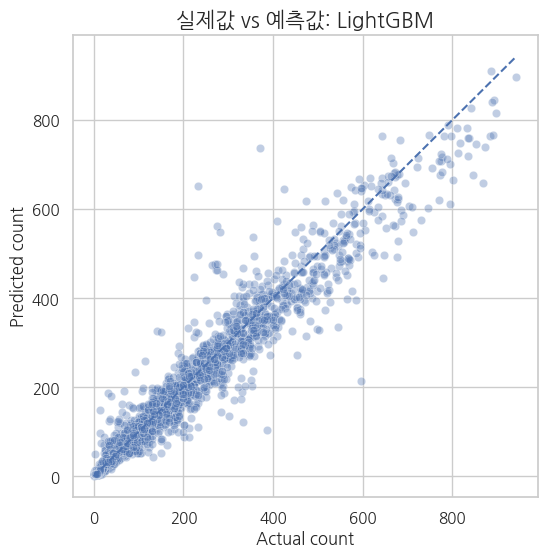

In [ ]:
plt.figure(figsize=(6, 6))
sns.scatterplot(x=valid_result['count'], y=valid_result['pred'], alpha=0.35)
max_value = max(valid_result['count'].max(), valid_result['pred'].max())
plt.plot([0, max_value], [0, max_value], linestyle='--')
plt.title(f'실제값 vs 예측값: {best_model_name}', fontsize=15, fontweight='bold')
plt.xlabel('Actual count')
plt.ylabel('Predicted count')
plt.show()


## 7-2. 시간대별 검증 오차 분석

모델이 어떤 시간대에서 약한지 확인하면 운영 및 피처 개선 방향을 찾을 수 있다.


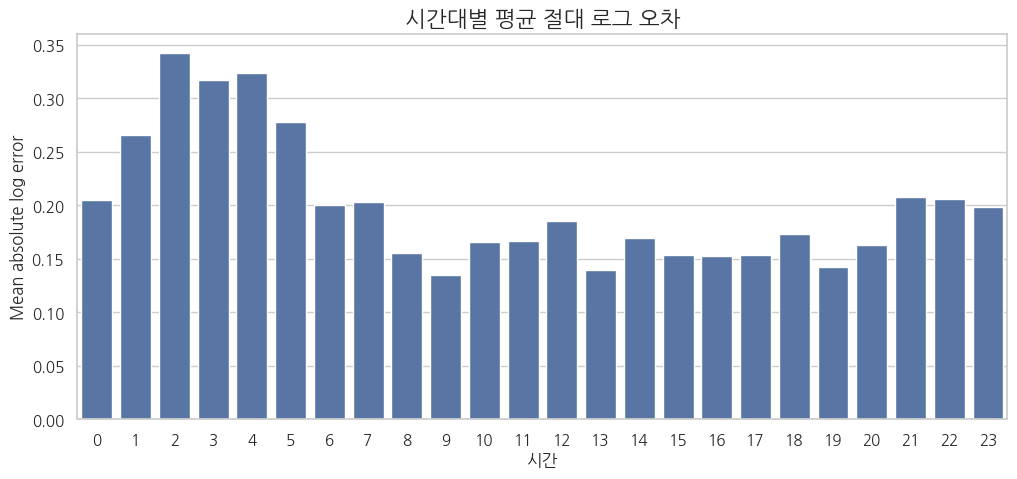

,hour,abs_log_error
2,2,0.342906
4,4,0.324043
3,3,0.317160
5,5,0.278045
1,1,0.266120
21,21,0.208090
22,22,0.205892
0,0,0.205451
7,7,0.203628
6,6,0.200369


In [ ]:
error_by_hour = valid_result.groupby('hour')['abs_log_error'].mean().reset_index()

plt.figure(figsize=(12, 5))
sns.barplot(data=error_by_hour, x='hour', y='abs_log_error')
plt.title('시간대별 평균 절대 로그 오차', fontsize=16, fontweight='bold')
plt.xlabel('시간')
plt.ylabel('Mean absolute log error')
plt.show()

display(error_by_hour.sort_values('abs_log_error', ascending=False).head(10))


In [ ]:
error_by_weather = valid_result.groupby('weather')['abs_log_error'].mean().reset_index()
error_by_weather['weather_name'] = error_by_weather['weather'].map(weather_labels)

display(error_by_weather.sort_values('abs_log_error', ascending=False))


,weather,abs_log_error,weather_name
2,3,0.411719,약한 비/눈
1,2,0.205755,구름/안개
0,1,0.170079,맑음


# 8. 피처 중요도 확인

트리 기반 모델은 피처 중요도를 통해 어떤 변수가 예측에 많이 기여했는지 확인할 수 있다. One-hot encoding 이후의 컬럼명을 복원해 상위 피처를 확인한다.


,feature,importance
79,dayofyear,1740
88,humidity_windspeed,1683
86,temp_humidity,1626
75,humidity,1546
89,comfort_index,1399
80,hour_sin,1356
77,day,1333
81,hour_cos,1296
87,temp_windspeed,1296
78,weekofyear,664


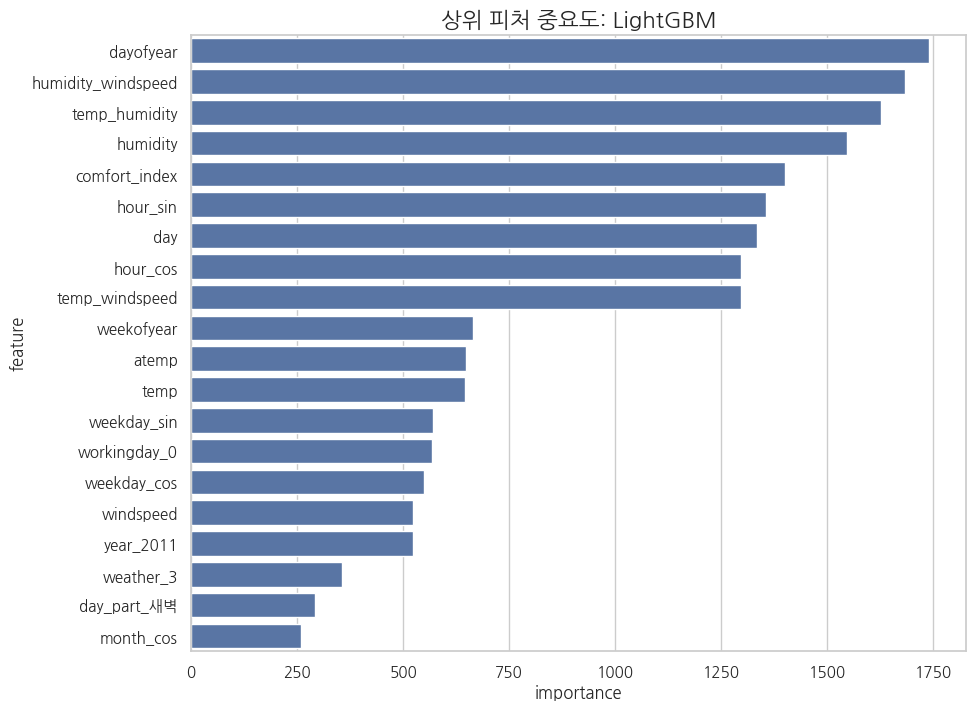

In [ ]:
def get_feature_names_from_preprocess(preprocessor):
    names = []
    for name, transformer, cols in preprocessor.transformers_:
        if name == 'cat':
            try:
                cat_names = transformer.get_feature_names_out(cols)
            except Exception:
                cat_names = transformer.get_feature_names(cols)
            names.extend(cat_names)
        elif name == 'num':
            names.extend(cols)
    return np.array(names)

try:
    fitted_preprocess = best_model.named_steps['preprocess']
    fitted_estimator = best_model.named_steps['model']
    feature_names = get_feature_names_from_preprocess(fitted_preprocess)

    if hasattr(fitted_estimator, 'feature_importances_'):
        importance_df = pd.DataFrame({
            'feature': feature_names,
            'importance': fitted_estimator.feature_importances_
        }).sort_values('importance', ascending=False)
    elif hasattr(fitted_estimator, 'coef_'):
        importance_df = pd.DataFrame({
            'feature': feature_names,
            'importance': np.abs(fitted_estimator.coef_)
        }).sort_values('importance', ascending=False)
    else:
        importance_df = pd.DataFrame()

    display(importance_df.head(30))

    if len(importance_df) > 0:
        plt.figure(figsize=(10, 8))
        sns.barplot(data=importance_df.head(20), x='importance', y='feature')
        plt.title(f'상위 피처 중요도: {best_model_name}', fontsize=16, fontweight='bold')
        plt.xlabel('importance')
        plt.ylabel('feature')
        plt.show()
except Exception as e:
    print('피처 중요도 계산 중 오류:', e)


# 9. 최종 모델 학습 및 제출 파일 생성

검증에서 선택된 모델 구조를 전체 train 데이터로 다시 학습한 뒤 test 데이터를 예측한다.


In [ ]:
# 최종 학습 데이터
X_all = train_fe[feature_cols]
y_all_log = np.log1p(train_fe['count'])
X_test = test_fe[feature_cols]

# 같은 모델 클래스를 새로 생성해 전체 데이터로 재학습
final_model = fitted_models[best_model_name]
final_model.fit(X_all, y_all_log)

test_pred = np.expm1(final_model.predict(X_test))
test_pred = np.clip(test_pred, 0, None)

submission = pd.DataFrame({
    'datetime': test_df['datetime'].dt.strftime('%Y-%m-%d %H:%M:%S'),
    'count': test_pred
})

# 대회 제출 파일은 보통 정수형 대여량을 요구하므로 반올림 버전도 함께 저장
submission_rounded = submission.copy()
submission_rounded['count'] = submission_rounded['count'].round().astype(int)

submission.to_csv('submission_float.csv', index=False)
submission_rounded.to_csv('submission.csv', index=False)

display(submission_rounded.head())
print('submission.csv 저장 완료')


,datetime,count
0,2011-01-20 00:00:00,11
1,2011-01-20 01:00:00,5
2,2011-01-20 02:00:00,3
3,2011-01-20 03:00:00,2
4,2011-01-20 04:00:00,2


submission.csv 저장 완료


# 10. 보고서용 최종 인사이트

## 10-1. 분석 인사이트

1. **시간대 효과가 가장 강하다**  
   시간대별 평균 대여량은 균등하지 않으며, 특히 출퇴근 시간대에서 수요가 집중된다. 따라서 `hour`, `rush_hour`, `morning_rush`, `evening_rush`는 핵심 피처로 사용해야 한다.

2. **요일과 근무일 여부는 수요 패턴을 바꾼다**  
   평일은 출퇴근형 패턴, 주말은 낮 시간대 중심의 분산형 패턴이 나타난다. 따라서 `weekday`, `workingday`, `is_weekend`를 함께 사용해야 한다.

3. **계절과 날씨는 수요 수준을 조정하는 변수다**  
   계절과 날씨 상태에 따라 대여량 분포 차이가 나타난다. 운영 관점에서는 날씨 악화 시 과잉 배치를 줄이고, 수요가 높은 계절에는 공급량을 선제적으로 늘릴 필요가 있다.

4. **RMSLE 기준에서는 로그 타깃 학습이 적합하다**  
   대여량이 큰 구간의 절대 오차보다 비율 오차가 중요하므로 `log1p(count)`를 타깃으로 학습하는 방식이 평가 지표와 잘 맞는다.

## 10-2. 운영 전략 제안

- **출퇴근 시간대 집중 배치**: 평일 7~9시, 17~19시에 주요 대여소의 자전거 재배치를 강화한다.
- **주말 낮 시간대 유연 배치**: 주말은 출퇴근 피크보다 낮 시간대 레저 수요에 맞춰 배치한다.
- **날씨 기반 공급 조정**: 비·눈·높은 습도 등 수요 감소 조건에서는 과잉 배치를 줄이고 정비·회수 업무를 배치한다.
- **계절별 운영 계획**: 수요가 높은 계절에는 가용 자전거 수와 정비 인력을 사전에 늘린다.

## 10-3. 모델 개선 방향

- 대여소 위치, 주변 시설, 이벤트, 강수량, 체감 날씨 등 외부 변수를 추가하면 성능 개선 가능성이 있다.
- 시간 기반 검증뿐 아니라 월별 교차검증을 추가하면 모델 안정성을 더 엄밀하게 확인할 수 있다.
- `casual`, `registered`를 각각 예측한 뒤 합산하는 two-stage 모델도 실험해볼 수 있지만, test에 해당 컬럼이 없으므로 반드시 별도 모델로 예측해야 한다.


# 11. 발표용 요약

이번 분석에서는 자전거 대여량을 단순 평균으로 예측하는 것이 아니라, 시간·요일·날씨·계절에 따라 수요가 어떻게 달라지는지를 먼저 확인했습니다. EDA 결과 평일에는 출퇴근 시간대에 수요가 집중되고, 주말에는 낮 시간대 중심으로 수요가 분산되는 패턴이 나타났습니다. 이 패턴이 우연인지 확인하기 위해 근무일 여부, 출퇴근 시간대, 계절, 날씨 변수에 대해 가설검정을 수행했고, 유의한 차이가 확인된 변수들을 모델 피처로 반영했습니다.

모델링 단계에서는 RMSLE 평가 지표에 맞춰 `count`를 그대로 예측하지 않고 `log1p(count)`를 타깃으로 학습했습니다. 또한 test 데이터가 미래 수요 예측 구조를 갖는다는 점을 고려해 각 월의 앞 날짜로 뒤 날짜를 예측하는 검증 구조를 만들었습니다. 최종적으로 여러 모델을 비교하여 validation RMSLE가 가장 낮은 모델을 선택했고, 이를 전체 train 데이터로 재학습해 test 예측 파일을 생성했습니다.

운영 관점에서는 평일 출퇴근 시간대 집중 배치, 주말 낮 시간대 유연 배치, 날씨 악화 시 공급량 조정, 계절별 사전 운영 계획이 필요하다는 결론을 도출했습니다.
